# Defining the Problem and Setting Objectives

<h3>What are the main characteristics that have the most impact on the customer spending score?</h3>


<h2 id="import_data">1. Importing the required libraries</h2>


In [4]:
import pandas as pd
import numpy as np
import scipy


print(pd.__version__)
print(np.__version__)
print(scipy.__version__)


2.3.2
2.2.5
1.14.1


Load the data and store it in dataframe `df`:


In [5]:
df = pd.read_csv('Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income ($),Spending Score (1-100),Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


<h2 id="pattern_visualization">2. Analyzing Individual Feature Patterns Using Visualization</h2>


To install Seaborn we use pip, the Python package manager. However, in this project, we are going to use matplotlib for our visualization.


Import visualization packages "Matplotlib" and "Seaborn". Let's not forget about "%matplotlib inline" to plot in a Jupyter notebook.


In [6]:
import matplotlib.pyplot as plt
%matplotlib inline 

<h4>How do we choose the right visualization method?</h4>
<p>When visualizing individual variables, it is important to first understand what type of variable we are dealing with. This will help us find the right visualization method for that variable.</p>


In [7]:
print(df.dtypes)

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income ($)          int64
Spending Score (1-100)     int64
Profession                object
Work Experience            int64
Family Size                int64
dtype: object


we can calculate the correlation between variables  of type "int64" or "float64" using the method "corr":

In [8]:
df.corr(numeric_only=True)

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
CustomerID,1.000000,0.070700,0.328400,0.018936,0.091574,0.159655
Age,0.070700,1.000000,0.021378,-0.041798,-0.014319,0.038254
Annual Income ($),0.328400,0.021378,1.000000,0.023299,0.089136,0.093005
Spending Score (1-100),0.018936,-0.041798,0.023299,1.000000,-0.028948,0.002232
Work Experience,0.091574,-0.014319,0.089136,-0.028948,1.000000,0.011873
Family Size,0.159655,0.038254,0.093005,0.002232,0.011873,1.000000


<p>In order to start understanding the (linear) relationship between an individual variable and the Spending Score (1-100), we can use "regplot" which plots the scatterplot plus the fitted regression line for the data. This will be useful later on for visualizing the fit of the simple linear regression model as well. </p>


<h2>Continuous Numerical Variables:</h2> 

Let's find the scatterplot of "Annual Income ($)" and "Spending Score (1-100)".


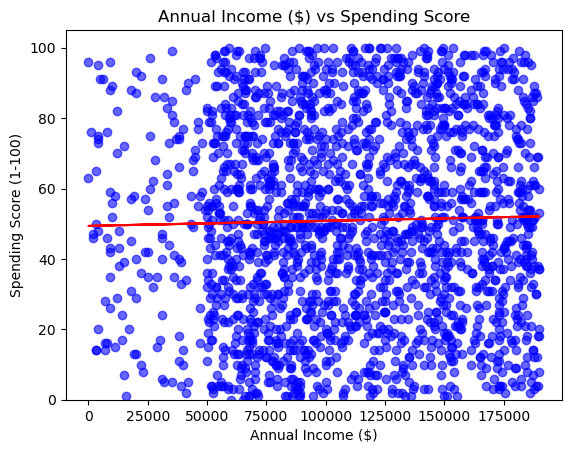

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Extract x and y data
x = df["Annual Income ($)"]
y = df["Spending Score (1-100)"]

# Scatter plot
plt.scatter(x, y, color="blue", alpha=0.6)

# Fit a regression line using numpy
m, b = np.polyfit(x, y, 1)   # slope and intercept
plt.plot(x, m*x + b, color="red")

# Set y-axis limit
plt.ylim(0,)

# Labels and title
plt.xlabel("Annual Income ($)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income ($) vs Spending Score")

plt.show()


<p>As the Annual Income ($) remains stable in the middle, the Spending Score (1-100) also remains the same: this indicates no direct correlation between these two variables. Annual Income does not seem like a good predictor of Spending Score since the regression line is almost a perfect horizontal line.</p>


 We can examine the correlation between 'Annual Income ($)' and 'Spending Score (1-100)' and see that it's approximately 0.02.


In [10]:
df[["Annual Income ($)", "Spending Score (1-100)"]].corr()

,Annual Income ($),Spending Score (1-100)
Annual Income ($),1.000000,0.023299
Spending Score (1-100),0.023299,1.000000


Let's find the scatterplot of "Age" and "Spending Score (1-100)".


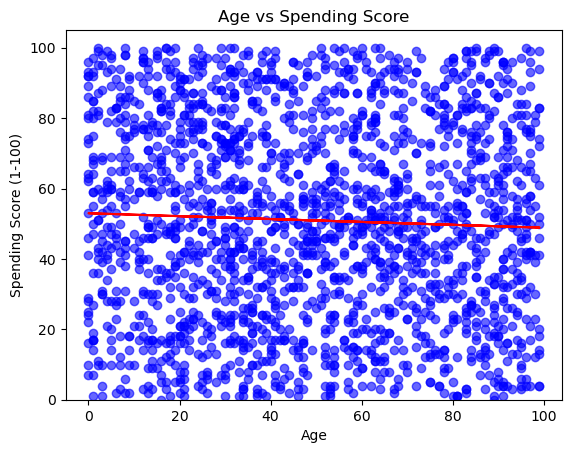

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Extract x and y data
x = df["Age"]
y = df["Spending Score (1-100)"]

# Scatter plot
plt.scatter(x, y, color="blue", alpha=0.6)

# Fit a regression line using numpy
slope, intercept = np.polyfit(x, y, 1)
plt.plot(x, slope * x + intercept, color="red")

# Set y-axis limit
plt.ylim(0,)

# Labels and title
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.title("Age vs Spending Score")

plt.show()


<p>As the Age remains stable in the middle, the Spending Score (1-100) also remains the same: this indicates no direct correlation between these two variables. Age does not seem like a good predictor of Spending Score since the regression line is almost a perfect horizontal line.</p>


 We can examine the correlation between 'Age' and 'Spending Score (1-100)' and see that it's approximately -0.04.


In [12]:
df[['Age', 'Spending Score (1-100)']].corr()

,Age,Spending Score (1-100)
Age,1.000000,-0.041798
Spending Score (1-100),-0.041798,1.000000


Let's find the scatterplot of "Work Experience" and "Spending Score (1-100)".


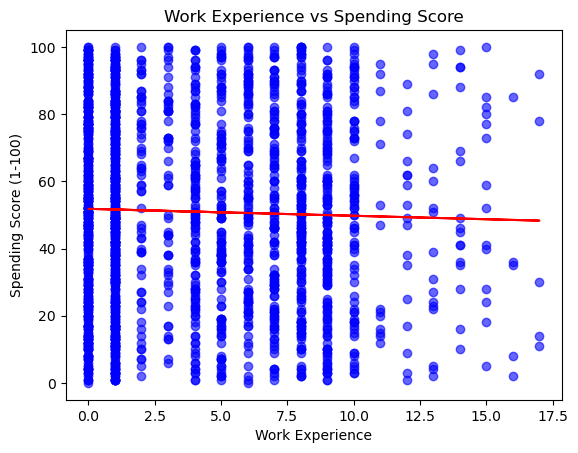

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Extract x and y data
x = df["Work Experience"]
y = df["Spending Score (1-100)"]

# Scatter plot
plt.scatter(x, y, color="blue", alpha=0.6)

# Fit a regression line using numpy
slope, intercept = np.polyfit(x, y, 1)
plt.plot(x, slope * x + intercept, color="red")

# Labels and title
plt.xlabel("Work Experience")
plt.ylabel("Spending Score (1-100)")
plt.title("Work Experience vs Spending Score")

plt.show()


<p>As the Work Experience remains stable in the middle, the Spending Score (1-100) also remains the same: this indicates no direct correlation between these two variables. Work Experience does not seem like a good predictor of Spending Score since the regression line is almost a perfect horizontal line.</p>


 We can examine the correlation between 'Work Experience' and 'Spending Score (1-100)' and see that it's approximately -0.03.


In [14]:
df[['Work Experience','Spending Score (1-100)']].corr()

,Work Experience,Spending Score (1-100)
Work Experience,1.000000,-0.028948
Spending Score (1-100),-0.028948,1.000000


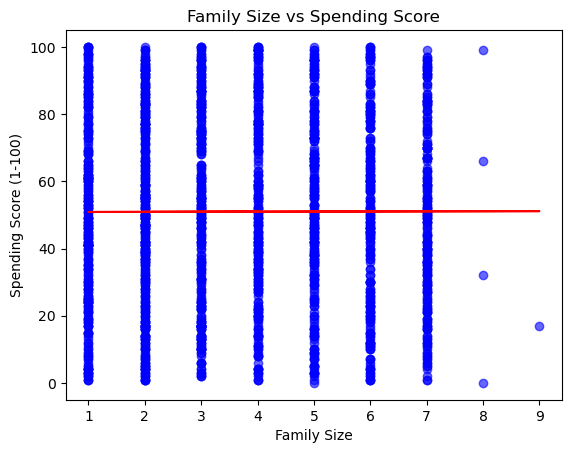

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Extract x and y data
x = df["Family Size"]
y = df["Spending Score (1-100)"]

# Scatter plot
plt.scatter(x, y, color="blue", alpha=0.6)

# Fit a regression line using numpy
slope, intercept = np.polyfit(x, y, 1)
plt.plot(x, slope * x + intercept, color="red")

# Labels and title
plt.xlabel("Family Size")
plt.ylabel("Spending Score (1-100)")
plt.title("Family Size vs Spending Score")

plt.show()


<p>As the Family Size remains stable in the middle, the Spending Score (1-100) also remains the same: this indicates no direct correlation between these two variables. Family Size does not seem like a good predictor of Spending Score since the regression line is almost a perfect horizontal line.</p>

 We can examine the correlation between 'Work Experience' and 'Spending Score (1-100)' and see that it's approximately -0.002.


In [16]:
df[['Family Size','Spending Score (1-100)']].corr()

,Family Size,Spending Score (1-100)
Family Size,1.000000,0.002232
Spending Score (1-100),0.002232,1.000000


<h3>Categorical Variables</h3>

 A good way to visualize categorical variables is by using boxplots.</p>
 Let's look at the relationship between "Gender" and "Spending Score (1-100)".


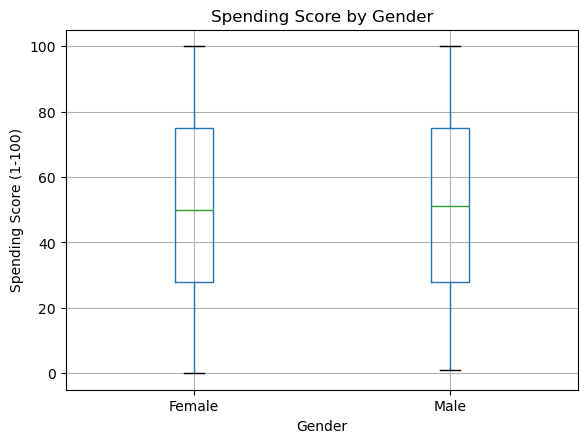

In [17]:
import matplotlib.pyplot as plt

# Extract data
x = df["Gender"]
y = df["Spending Score (1-100)"]

# Create boxplot grouped by Gender
df.boxplot(column="Spending Score (1-100)", by="Gender")

# Labels and title
plt.xlabel("Gender")
plt.ylabel("Spending Score (1-100)")
plt.title("Spending Score by Gender")
plt.suptitle("")  # Remove automatic 'Boxplot grouped by' title

plt.show()


<p>We see that the distributions of Spending Score ($) between the different Gender categories have a significant overlap, so Gender would not be a good predictor of price. Let's examine "Gender" and "Spending Score (1-100)":</p>


 Let's look at the relationship between "Profession" and "Spending Score (1-100)".

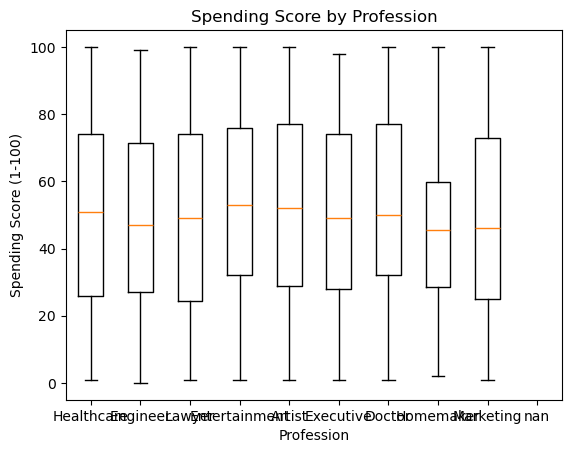

In [18]:
import matplotlib.pyplot as plt

# Get unique professions
professions = df["Profession"].unique()

# Prepare data grouped by profession
data = [df[df["Profession"] == p]["Spending Score (1-100)"] for p in professions]

# Create boxplot
plt.boxplot(data, labels=professions)

# Labels and title
plt.xlabel("Profession")
plt.ylabel("Spending Score (1-100)")
plt.title("Spending Score by Profession")

plt.show()


<p>We see that the distributions of Spending Score ($) between the different Profession categories have a significant overlap, so Profession would not be a good predictor of price. Let's examine "Profession" and "Spending Score (1-100)":</p>


<h2 id="discriptive_statistics">3. Descriptive Statistical Analysis</h2>


<p>Let's first take a look at the variables by utilizing a description method.</p>

<p>The <b>describe</b> function automatically computes basic statistics for all continuous variables.

We can apply the method "describe" as follows:

In [19]:
df.describe()

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,48.960000,110731.821500,50.962500,4.102500,3.768500
std,577.494589,28.429747,45739.536688,27.934661,3.922204,1.970749
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,500.750000,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,1000.500000,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,1500.250000,73.000000,149092.750000,75.000000,7.000000,5.000000
max,2000.000000,99.000000,189974.000000,100.000000,17.000000,9.000000


 The default setting of "describe" skips variables of type object. We can apply the method "describe" on the variables of type 'object' as follows:


In [20]:
df.describe(include=['object'])

,Gender,Profession
count,2000,1965
unique,2,9
top,Female,Artist
freq,1186,612


<h3>Value Counts</h3>


The value_counts method in Pandas is useful for seeing how many instances each category has in a variable. It must be applied to a Series (a single column), not a DataFrame. Therefore, we should use single brackets like df['Gender'] instead of double brackets df[['Gender']].

In [21]:
df['Gender'].value_counts()

Gender
Female    1186
Male       814
Name: count, dtype: int64

We can convert the series to a dataframe as follows:


In [22]:
df['Gender'].value_counts().to_frame()

,count
Gender,
Female,1186
Male,814


Let's repeat the above steps but save the results to the dataframe "gender_counts" and rename the column  'Gender' to 'value_counts'.


In [23]:
gender_counts = df['Gender'].value_counts().to_frame()
gender_counts.rename(columns={'Gender': 'value_counts'}, inplace=True)
gender_counts

,count
Gender,
Female,1186
Male,814


 Now let's rename the index to 'Gender':


In [24]:
gender_counts.index.name = 'Gender'
gender_counts

,count
Gender,
Female,1186
Male,814


We can repeat the above process for the variable 'Profession'.


In [25]:
# engine-location as variable
profession_counts = df['Profession'].value_counts().to_frame()
profession_counts.rename(columns={'Profession': 'value_counts'}, inplace=True)
profession_counts.index.name = 'Profession'
profession_counts.head(10)

,count
Profession,
Artist,612
Healthcare,339
Entertainment,234
Engineer,179
Doctor,161
Executive,153
Lawyer,142
Marketing,85
Homemaker,60


Profession is not a reliable predictor of Spending Score because there is a weak correlation between them

<h2 id="basic_grouping">4. Basics of Grouping</h2>


The groupby method in Pandas is used to organize data into groups based on one or more variables, allowing analysis within each group. For example, grouping by "Profession" separates the data into three categories of Profession, making it easier to compare and analyze each category individually.

In [26]:
df['Profession'].unique()

array(['Healthcare', 'Engineer', 'Lawyer', 'Entertainment', 'Artist',
       'Executive', 'Doctor', 'Homemaker', 'Marketing', nan], dtype=object)

<p>If we want to know, on average, which type of Profession is most valuable, we can group "Profession" and then average them.</p>

<p>We can select the columns 'Annual Income', 'Age' and 'Spending Score', then assign it to the variable "df_group_one".</p>

In [27]:
df_group_one = df[['Annual Income ($)','Age','Spending Score (1-100)']]

We can then calculate the average price for each of the different categories of data.


In [28]:
# grouping results
df_group_one = df_group_one.groupby(['Annual Income ($)'],as_index=False).mean()
df_group_one

,Annual Income ($),Age,Spending Score (1-100)
0,0,27.500000,79.500000
1,1000,96.000000,76.000000
2,2000,33.000000,46.500000
3,3000,55.750000,35.750000
4,4000,37.833333,64.166667
...,...,...,...
1781,189672,59.000000,8.000000
1782,189689,16.000000,37.000000
1783,189709,7.000000,18.000000
1784,189945,60.000000,20.000000


Annual Income less than or equal to 1000 tend have higher Spending Score on average, while greater than or equal to 1000 have lesser Spending Score. Data can also be grouped by multiple variables; for instance, grouping by both Annual Income and Age creates combinations of these categories, and the results can be stored in a variable such as grouped_test1.

In [29]:
# grouping results
df_gptest = df[['Annual Income ($)','Age',]]
grouped_test1 = df_gptest.groupby(['Annual Income ($)','Age'],as_index=False).mean()
grouped_test1

,Annual Income ($),Age
0,0,23
1,0,32
2,1000,96
3,2000,19
4,2000,47
...,...,...
1991,189672,59
1992,189689,16
1993,189709,7
1994,189945,60


<p>This grouped data is much easier to visualize when it is made into a pivot table. A pivot table is like an Excel spreadsheet, with one variable along the column and another along the row. We can convert the dataframe to a pivot table using the method "pivot" to create a pivot table from the groups.</p>

<p>In this case, we will leave the Annual Income variable as the rows of the table, and pivot Age to become the columns of the table:</p>

In [30]:
grouped_pivot = grouped_test1.pivot(index='Annual Income ($)',columns='Age')
grouped_pivot

Annual Income ($)
0
1000
2000
3000
4000
...
189672
189689
189709
189945


If we did not import "pyplot", let's do it again. 

In [31]:
import matplotlib.pyplot as plt
%matplotlib inline 

Let's use a heat map to visualize the relationship between Annual Income vs Spending Score.


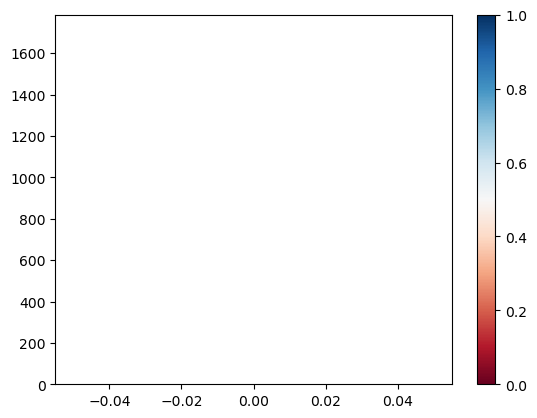

In [32]:
#use the grouped results
plt.pcolor(grouped_pivot, cmap='RdBu')
plt.colorbar()
plt.show()

<h2 id="correlation_causation">5. Correlation and Causation</h2>


<p>Pearson Correlation is the default method of the function "corr". Like before, we can calculate the Pearson Correlation of the 'int64' or 'float64'  variables.</p>

In [33]:
df.corr(numeric_only=True)

,CustomerID,Age,Annual Income ($),Spending Score (1-100),Work Experience,Family Size
CustomerID,1.000000,0.070700,0.328400,0.018936,0.091574,0.159655
Age,0.070700,1.000000,0.021378,-0.041798,-0.014319,0.038254
Annual Income ($),0.328400,0.021378,1.000000,0.023299,0.089136,0.093005
Spending Score (1-100),0.018936,-0.041798,0.023299,1.000000,-0.028948,0.002232
Work Experience,0.091574,-0.014319,0.089136,-0.028948,1.000000,0.011873
Family Size,0.159655,0.038254,0.093005,0.002232,0.011873,1.000000


Sometimes we would like to know the significant of the correlation estimate. 


The smaller the p‑value, the stronger the evidence that the correlation is meaningful.
 We can obtain this information using  "stats" module in the "scipy"  library.


In [34]:
from scipy import stats

<h3>Age vs. Spending Score</h3>


Let's calculate the  Pearson Correlation Coefficient and P-value of 'Age' and 'Spending Score'. 


In [35]:
pearson_coef, p_value = stats.pearsonr(df['Age'], df['Spending Score (1-100)'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value) 

The Pearson Correlation Coefficient is -0.04179819727007073  with a P-value of P = 0.06163390072607035


<h4>Conclusion:</h4>
<p>Since the p-value is $<$ 0.1, the correlation between Age and Spending Score is not quite statistically significant, although the linear relationship isn't extremely strong either (~-0.04).</p>


<h3>Annual Income vs. Spending Score</h3>


Let's calculate the  Pearson Correlation Coefficient and P-value of 'Annual Income' and 'Spending Score'. 

In [36]:
pearson_coef, p_value = stats.pearsonr(df['Annual Income ($)'], df['Spending Score (1-100)'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is 0.02329940462632605  with a P-value of P =  0.29765700644057985


<h4>Conclusion:</h4>
<p>Since the p-value is $>$ 0.1, the correlation between Annual Income and Spending Score is not statistically significant, although the linear relationship isn't extremely strong either (~0.02).</p>


<h3>Work Experience vs. Spending Score</h3>


Let's calculate the  Pearson Correlation Coefficient and P-value of 'Work Experience' and 'Spending Score'. 

In [37]:
pearson_coef, p_value = stats.pearsonr(df['Work Experience'], df['Spending Score (1-100)'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P = ", p_value)  

The Pearson Correlation Coefficient is -0.02894838046730818  with a P-value of P =  0.19564029121305604


<h4>Conclusion:</h4>
<p>Since the p-value is $>$ 0.1, the correlation between Work Experience and Spending Score is not statistically significant, although the linear relationship isn't extremely strong either (~-0.02).</p>


<h3>Family Size vs. Spending Score</h3>


Let's calculate the  Pearson Correlation Coefficient and P-value of 'Family Size' and 'Spending Score'. 

In [38]:
pearson_coef, p_value = stats.pearsonr(df['Family Size'], df['Spending Score (1-100)'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value ) 

The Pearson Correlation Coefficient is 0.0022320672141412784  with a P-value of P = 0.9205358188054006


<h4>Conclusion:</h4>
<p>Since the p-value is $>$ 0.1, the correlation between Family Size and Spending Score is not statistically significant, although the linear relationship isn't extremely strong either (~0.002).</p>


<h3>Conclusion: Important Variables</h3>


Continuous numerical variables:
<ul>
    <li>Age</li>
    <li>Annual Income</li>
    <li>Work Experience</li>
    <li>Family Size</li>
</ul>
    
Categorical variables:
<ul>
    <li>Gender</li>
    <li>Profession</li>
</ul>